# Model Evaluation & Refinement: Laptops

The same evaluation toolkit on the laptop data: cross-validation, overfitting across polynomial degrees, a Ridge alpha sweep, and grid search.

*Lab from IBM's **Data Analysis with Python** course (Coursera), documented in my own words.*

**Skills:** cross-validation, polynomial degree selection, `Ridge`, `GridSearchCV`

## Load the data

In [1]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

In [4]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv'
df = pd.read_csv(filepath, header=0)

In [5]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [6]:
df = df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1)

## Using Cross validation to improve the model

In [7]:
y_data = df['Price']
x_data = df.drop('Price', axis=1)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size= 0.10, random_state=1)
print("number of test samples :", x_test.shape[0])
print("number of training samples :", x_train.shape[0])

number of test samples : 24
number of training samples : 214


In [10]:
lre = LinearRegression()
lre.fit(x_train[["CPU_frequency"]], y_train)
print(f"R^2 Training score:{lre.score(x_train[["CPU_frequency"]], y_train)}")
print(f"R^2 Testing score:{lre.score(x_test[["CPU_frequency"]], y_test)}")

R^2 Training score:0.14829792099817973
R^2 Testing score:-0.06599437350393766


In [13]:
Rcross = cross_val_score(lre, x_train[["CPU_frequency"]], y_train, cv=4)
print(f"\nAverage R^2 score= {Rcross.mean()} & std score= {Rcross.std()}")


Average R^2 score= 0.12738818019555026 & std score= 0.0831705801091202


## Overfitting

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5, random_state=1)

In [22]:
r2sqr = []
degrees = [1, 2, 3, 4, 5]
for n in degrees:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[["CPU_frequency"]])
    x_test_pr = pr.fit_transform(x_test[["CPU_frequency"]])
    model = LinearRegression()
    model.fit(x_train_pr, y_train)
    score = model.score(x_test_pr, y_test)
    r2sqr.append(score)
    print(f"\nend={n}, R^2 score={score}")


end=1, R^2 score=0.0286194117201638

end=2, R^2 score=0.14520883323304978

end=3, R^2 score=0.15681605330238746

end=4, R^2 score=0.12721267717783413

end=5, R^2 score=0.035470646024037045


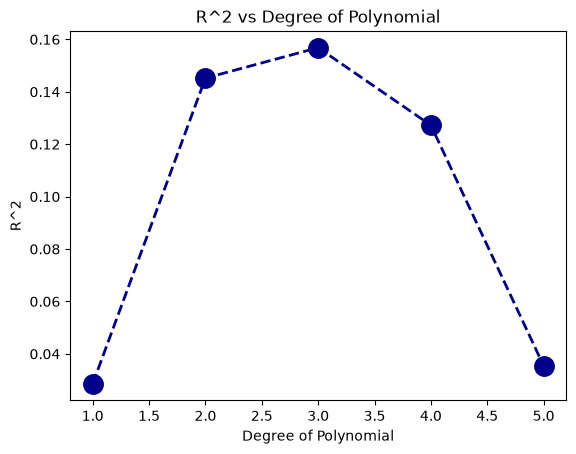

In [43]:
plt.plot(degrees, r2sqr, color='darkblue', marker='o', linestyle='dashed', linewidth=2, markersize=14)

plt.title('R^2 vs Degree of Polynomial')
plt.xlabel('Degree of Polynomial')
plt.ylabel('R^2')
plt.show()

## Ridge Regression

In [44]:
pr1 = PolynomialFeatures(degree=2)
x_train_pr1 = pr1.fit_transform(x_train[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']])
x_test_pr1 = pr1.fit_transform(x_test[['CPU_frequency','RAM_GB','Storage_GB_SSD','CPU_core','OS','GPU','Category']])
model1 = LinearRegression().fit(x_test_pr1, y_test)
model1

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](36,)","[ -0. , 279.12,-152.78,...,-209.03, 5.1 , 133.62]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,999.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](36,)","[134351.45, 5780.29, 2755.71,..., 0. , 0. , 0. ]"


In [45]:
train_scores = []
test_scores = []
Alpha = np.arange(0.001, 1, 0.001)
pbar = tqdm(Alpha, desc="Training Ridge Models")

for alpha in pbar:
    RidgeModel = Ridge(alpha=alpha)
    RidgeModel.fit(x_train_pr1, y_train)
    test_score, train_score = RidgeModel.score(x_test_pr1, y_test), RidgeModel.score(x_train_pr1, y_train)
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})
    test_scores.append(test_score)
    train_scores.append(train_score)

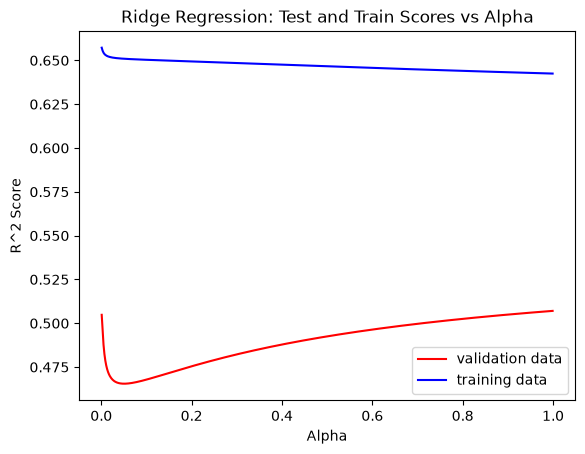

In [53]:
plt.plot(Alpha, test_scores, color='red', label='validation data')
plt.plot(Alpha, train_scores, color='blue', label='training data')
plt.title('Ridge Regression: Test and Train Scores vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('R^2 Score')
# plt.ylim(0, 1)
plt.legend()

## Grid Search

In [54]:
parameters1 = [{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}]

In [55]:
rg = Ridge()
grid = GridSearchCV(rg, parameters1, cv=4)

In [56]:
grid.fit(x_train_pr1, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'alpha': [0.0001, 0.001, ...]}]"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yieldi

In [57]:
bestRR= grid.best_estimator_
r_2_scr = grid.score(x_test_pr1, y_test)
print(bestRR.score(x_test_pr1, y_test))

0.5296942064190279


## What I took away

- The train/test gap across polynomial degrees shows exactly where extra flexibility stops helping.
- Grid search tries every alpha with cross-validation and keeps the winner, which beats picking alpha by hand.